# Lyapunov-Certified Cascade Controller for a Quadrotor UAV
 
## Problem statement
 
A quadrotor must track the horizontal circle
 
$$p_d(t) = \bigl[R\cos(\omega t),\; R\sin(\omega t),\; z_d\bigr]^\top,
\qquad R = 3\;\text{m},\quad \omega = 0.5\;\text{rad/s},\quad z_d = 3\;\text{m}$$
 
starting from rest at $[0,\,0,\,0.5]$ m, using real motor forces integrated by
the MuJoCo physics engine.
 
## Control architecture
 
The controller is a **two-tier geometric cascade**:
 
| Tier | Role | Lyapunov status |
|------|------|-----------------|
| **Outer loop** (position) | $\mathbf{v}_\text{cmd} = \mathbf{v}_d - K\mathbf{e}_p$ | **GAS** — no caveats |
| **Inner loop** (attitude, SO(3)) | $\boldsymbol{\tau} = -k_R\mathbf{e}_R - k_\Omega\mathbf{e}_\Omega + \boldsymbol{\Omega}\times J\boldsymbol{\Omega}$ | **GAS** after gyroscopic fix |
 
## What this notebook proves and shows
 
1. **Tier 1** is GAS by Lyapunov's Direct Method — $\dot V_1 < 0$ everywhere.
2. **Tier 2** requires the gyroscopic cancellation $\boldsymbol{\Omega}\times J\boldsymbol{\Omega}$
   to restore its certificate (Lee et al. 2010). Without it, $\dot V_2$ retains
   cross-terms that prevent negative definiteness.
3. The **combined cascade** is GAS via the sum $V_\text{total} = V_1 + V_2$.
4. Motor forces are **not clipped** so the global certificate holds. Saturation
   is left as future work (Control Barrier Functions).
5. A final section compares **trajectory tracking** with **path following**
   and explains why trajectory tracking consistently outperforms path following
   for this specific problem.

## Import Section

In [1]:
import sys
from pathlib import Path
 
cwd  = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
 
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm
from IPython.display import Math, display, Video
 
from src.simulation.video_sim import VideoSim
from src.utils.config import load_config
from src.utils.plotting import set_style, FigureManager
from src.control.cascade_controller import QuadState, QuadReference, CascadeController
from src.control.certified_cascade_controller import CertifiedCascadeController
from src.symbolic.quadcopter_certified_lyapunov import (
    derive_kinematic_certificate,
    derive_attitude_lyapunov,
    derive_full_lyapunov,
    derive_gyroscopic_fix,
)
 
set_style()

## Lyapunov Analysis 

In [2]:
kin = derive_kinematic_certificate()
 
display(Math(r"\textbf{Tier 1 — Kinematic Outer Loop}"))
 
display(Math(r"\textbf{Lyapunov candidate:}"))
display(Math(r"V_1(\mathbf{e}) = " + sp.latex(kin["V"])))
 
display(Math(
    r"\textbf{Positive Definite (PD):}\quad "
    r"V_1 > 0\ \forall\,\mathbf{e}\neq 0,\quad V_1(0)=0,\quad "
    r"V_1 \to \infty\ \text{as}\ \|\mathbf{e}\|\to\infty\quad\text{(radially unbounded)}"
))
 
display(Math(
    r"\textbf{Error dynamics under }"
    r"\mathbf{v}_\mathrm{cmd} = \mathbf{v}_d - K\mathbf{e}\textbf{:}"
))
display(Math(r"\dot{\mathbf{e}} = " + sp.latex(kin["e_dot"])))
 
display(Math(r"\textbf{Time derivative:}"))
display(Math(
    r"\dot{V}_1 = \nabla V_1 \cdot \dot{\mathbf{e}} = \mathbf{e}^\top\dot{\mathbf{e}} = "
    + sp.latex(kin["V_dot"])
))
 
display(Math(
    r"\textbf{Negative Definite (ND):}\quad "
    r"\dot{V}_1 = -\mathbf{e}^\top K\mathbf{e} < 0\ \forall\,\mathbf{e}\neq 0"
    r"\quad\text{since }k_i > 0"
))
 
display(Math(
    r"\textbf{LaSalle invariant set:}\quad "
    r"\mathcal{S} = \{\mathbf{e}:\dot{V}_1=0\} = \{\mathbf{0}\}"
    r"\quad\Rightarrow\quad\mathcal{M} = \{\mathbf{0}\}"
))
 
display(Math(
    r"\therefore\quad\mathbf{e}(t)\to\mathbf{0}\ \text{as}\ t\to\infty"
    r"\quad\textbf{(Globally Asymptotically Stable — no caveats)}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
att = derive_attitude_lyapunov()
fix = derive_gyroscopic_fix()
 
display(Math(r"\textbf{Tier 2 — Attitude Inner Loop (Lee et al. 2010)}"))
 
display(Math(r"\textbf{Lyapunov candidate (quadratic approx near equilibrium):}"))
display(Math(r"V_2(\mathbf{e}_R,\mathbf{e}_\Omega) = " + sp.latex(att["V_att"])))
 
display(Math(
    r"\textbf{PD:}\quad V_2 > 0\ \forall\,(\mathbf{e}_R,\mathbf{e}_\Omega)"
    r"\neq(\mathbf{0},\mathbf{0})\quad\text{since }k_R > 0,\;J\succ 0"
))
 
display(Math(r"\textbf{Without gyroscopic cancellation — certificate broken:}"))
display(Math(r"\boldsymbol{\tau}_\text{broken} = " + sp.latex(att["tau_no_fix"])))
display(Math(
    r"\dot{V}_2\big|_\text{broken} = " + sp.latex(att["V_att_dot_broken"])
))
display(Math(
    r"\Rightarrow\text{ cross terms }\mathbf{e}_R^\top\mathbf{e}_\Omega"
    r"\text{ remain}\;\Rightarrow\;\dot{V}_2\text{ is \textbf{not} ND}"
))
 
display(Math(r"\textbf{One-line fix: add }\boldsymbol{\Omega}\times J\boldsymbol{\Omega}"))
display(Math(r"\boldsymbol{\tau}_\text{cert} = " + sp.latex(fix["tau_fixed"])))
display(Math(r"\text{Gyroscopic term: }" + sp.latex(fix["gyro_term"])))
display(Math(
    r"\text{Residual feedforward (constant-}\omega\text{ circle): }"
    + sp.latex(fix["residual_ff_at_hover"])
    + r"\;=\;\mathbf{0}\quad\text{(vanishes for constant }\omega\text{)}"
))
display(Math(
    r"\dot{V}_2\big|_\text{cert} = "
    + sp.latex(sp.expand(att["V_att_dot_cert"]))
))
display(Math(
    r"\textbf{ND:}\quad\dot{V}_2 = -k_R\|\mathbf{e}_R\|^2 - k_w\|\mathbf{e}_\Omega\|^2 < 0"
    r"\ \forall\,(\mathbf{e}_R,\mathbf{e}_\Omega)\neq(\mathbf{0},\mathbf{0})"
))
display(Math(
    r"\textbf{LaSalle:}\quad"
    r"\mathcal{S}_\text{att} = \{(\mathbf{e}_R,\mathbf{e}_\Omega):\dot{V}_2=0\}"
    r"= \{(\mathbf{0},\mathbf{0})\}"
    r"\;\Rightarrow\;\mathcal{M}_\text{att}=\{(\mathbf{0},\mathbf{0})\}"
    r"\quad\textbf{(attitude GAS)}"
))
 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:

full = derive_full_lyapunov()
 
display(Math(r"\textbf{Full Cascade — Combined Lyapunov Function}"))
 
display(Math(
    r"V_\mathrm{total} = V_1 + V_2 = "
    + sp.latex(full["V_total"])
))
 
display(Math(
    r"\dot{V}_\mathrm{total} = \dot{V}_1 + \dot{V}_2 = "
    + sp.latex(full["V_total_dot"])
))
 
display(Math(
    r"\textbf{ND:}\quad\dot{V}_\mathrm{total} < 0"
    r"\ \forall\,(\mathbf{e}_p,\mathbf{e}_R,\mathbf{e}_\Omega)\neq\mathbf{0}"
    r"\quad\text{(all gains positive, }J\succ 0\text{)}"
))
 
display(Math(
    r"\textbf{LaSalle:}\quad"
    r"\mathcal{S} = \{\mathbf{e}_p=\mathbf{0}\}\cap\{\mathbf{e}_R=\mathbf{0}\}"
    r"\cap\{\mathbf{e}_\Omega=\mathbf{0}\} = \{\mathbf{0}\}"
))
 
display(Math(
    r"\mathcal{M} = \{\mathbf{0}\}"
    r"\quad\Longrightarrow\quad"
    r"\boxed{\text{Full cascade is Globally Asymptotically Stable (GAS)}}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Setup of the simulation

In [5]:
cert_config_path = str(ROOT / "config/quadcopter_certified_circle.yaml")
cert_cfg         = load_config(cert_config_path)
fm_cert          = FigureManager(cert_cfg, base_dir=ROOT)
 
dyn_config_path  = str(ROOT / "config/quadcopter_dynamic_circle.yaml")
dyn_cfg          = load_config(dyn_config_path)
fm_dyn           = FigureManager(dyn_cfg, base_dir=ROOT)

In [6]:
class QuadcopterCertifiedSim(VideoSim):
    """
    Certified cascade controller.
    Identical to the uncertified version except it uses
    CertifiedCascadeController, which adds Ω × JΩ to the torque law.
    J is read directly from the MuJoCo model so the cancellation is exact.
    """
 
    def __init__(self, config_path):
        super().__init__(config_path)
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model requires a free root joint.")
        self.data.qpos[:3]  = [0.0, 0.0, 0.5]
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]
        self.data.qvel[:]   = 0.0
        self._ctrl = CertifiedCascadeController.from_model(cert_cfg, self.model)
        traj = cert_cfg.get("trajectory", {})
        self.R, self.omega, self.z_d = (
            traj.get("radius", 3.0), traj.get("omega", 0.5), traj.get("z_height", 3.0)
        )
        cam = cert_cfg.get("camera", {})
        self._cam_lookat    = np.array(cam.get("lookat",    [0.0, 0.0, 2.0]))
        self._cam_distance  = float(cam.get("distance",  12.0))
        self._cam_elevation = float(cam.get("elevation", -30.0))
        self._cam_azimuth   = float(cam.get("azimuth",   45.0))
 
    def _reference(self, t):
        return QuadReference(
            pos      = np.array([ self.R * np.cos(self.omega * t),
                                   self.R * np.sin(self.omega * t), self.z_d]),
            vel      = np.array([-self.R * self.omega * np.sin(self.omega * t),
                                   self.R * self.omega * np.cos(self.omega * t), 0.0]),
            yaw      = self.omega * t + np.pi / 2.0,
            yaw_rate = self.omega,
        )

    # def _reference(self, t):
    #     # Smooth ramp factor: 0 at t=0, approaches 1 as t increases
    #     # Reaches ~95% of full aggression around t = 6 seconds
    #     ramp = 1.0 - np.exp(-t / 2.0)
    #     
    #     # Scale down parameters during the transient phase
    #     R = 3.0 * ramp
    #     w_orbit = 1.5 * ramp
    #     w_spin = 4.0 * ramp
    #     
    #     # Altitude target ramps from initial 0.5 up to 3.0
    #     z_d = 0.5 + (2.5 * ramp)
    #     
    #     return QuadReference(
    #         pos      = np.array([ R * np.cos(w_orbit * t),
    #                               R * np.sin(w_orbit * t), 
    #                               z_d]),
    #         vel      = np.array([-R * w_orbit * np.sin(w_orbit * t),
    #                               R * w_orbit * np.cos(w_orbit * t), 
    #                               0.5 * np.exp(-t / 2.0)]), # smooth z velocity component
    #         yaw      = w_spin * t,  
    #         yaw_rate = w_spin,
    #     )
 
    def _capture_frame(self):
        self._camera.lookat[:]  = self.data.qpos[:3]
        self._camera.distance   = self._cam_distance
        self._camera.elevation  = self._cam_elevation
        self._camera.azimuth    = self._cam_azimuth
        self._renderer.update_scene(self.data, camera=self._camera)
        self._frames.append(self._renderer.render())
 
    def _loop_step(self, t, step):
        state = QuadState(
            pos    = self.data.qpos[:3].copy(),
            quat   = self.data.qpos[3:7].copy(),
            vel    = self.data.qvel[:3].copy(),
            angvel = self.data.qvel[3:6].copy(),
        )
        ref = self._reference(t)
        forces, ctrl_log = self._ctrl.compute(state, ref)
        self.data.ctrl[:] = forces
        qw, qx, qy, qz = state.quat
        self.logger.log({
            "x":     float(state.pos[0]),
            "y":     float(state.pos[1]),
            "z":     float(state.pos[2]),
            "roll":  float(np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))),
            "pitch": float(np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))),
            "yaw":   float(np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))),
            "xd": float(ref.pos[0]), "yd": float(ref.pos[1]), "zd": float(ref.pos[2]),
            "psid": float(ref.yaw),
            "angvel_x": float(state.angvel[0]),
            "angvel_y": float(state.angvel[1]),
            "angvel_z": float(state.angvel[2]),
            **ctrl_log,
        })

In [7]:
class QuadcopterDynamicSim(VideoSim):
    """Uncertified cascade controller (no Ω × JΩ)."""
 
    def __init__(self, config_path):
        super().__init__(config_path)
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model requires a free root joint.")
        self.data.qpos[:3]  = [0.0, 0.0, 0.5]
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]
        self.data.qvel[:]   = 0.0
        self._ctrl = CascadeController.from_config(dyn_cfg)
        traj = dyn_cfg.get("trajectory", {})
        self.R, self.omega, self.z_d = (
            traj.get("radius", 3.0), traj.get("omega", 0.5), traj.get("z_height", 3.0)
        )
        cam = dyn_cfg.get("camera", {})
        self._cam_lookat    = np.array(cam.get("lookat",    [0.0, 0.0, 2.0]))
        self._cam_distance  = float(cam.get("distance",  12.0))
        self._cam_elevation = float(cam.get("elevation", -30.0))
        self._cam_azimuth   = float(cam.get("azimuth",   45.0))
 
    def _reference(self, t):
        return QuadReference(
            pos      = np.array([ self.R * np.cos(self.omega * t),
                                   self.R * np.sin(self.omega * t), self.z_d]),
            vel      = np.array([-self.R * self.omega * np.sin(self.omega * t),
                                   self.R * self.omega * np.cos(self.omega * t), 0.0]),
            yaw      = self.omega * t + np.pi / 2.0,
            yaw_rate = self.omega,
        )
    
    #def _reference(self, t):
    #    # Smooth ramp factor: 0 at t=0, approaches 1 as t increases
    #    # Reaches ~95% of full aggression around t = 6 seconds
    #    ramp = 1.0 - np.exp(-t / 2.0)
    #    
    #    # Scale down parameters during the transient phase
    #    R = 3.0 * ramp
    #    w_orbit = 1.5 * ramp
    #    w_spin = 4.0 * ramp
    #    
    #    # Altitude target ramps from initial 0.5 up to 3.0
    #    z_d = 0.5 + (2.5 * ramp)
    #    
    #    return QuadReference(
    #        pos      = np.array([ R * np.cos(w_orbit * t),
    #                              R * np.sin(w_orbit * t), 
    #                              z_d]),
    #        vel      = np.array([-R * w_orbit * np.sin(w_orbit * t),
    #                              R * w_orbit * np.cos(w_orbit * t), 
    #                              0.5 * np.exp(-t / 2.0)]), # smooth z velocity component
    #        yaw      = w_spin * t,  
    #        yaw_rate = w_spin,
    #    )
 
    def _capture_frame(self):
        self._camera.lookat[:]  = self.data.qpos[:3]
        self._camera.distance   = self._cam_distance
        self._camera.elevation  = self._cam_elevation
        self._camera.azimuth    = self._cam_azimuth
        self._renderer.update_scene(self.data, camera=self._camera)
        self._frames.append(self._renderer.render())
 
    def _loop_step(self, t, step):
        state = QuadState(
            pos    = self.data.qpos[:3].copy(),
            quat   = self.data.qpos[3:7].copy(),
            vel    = self.data.qvel[:3].copy(),
            angvel = self.data.qvel[3:6].copy(),
        )
        ref = self._reference(t)
        forces, ctrl_log = self._ctrl.compute(state, ref)
        self.data.ctrl[:] = forces
        qw, qx, qy, qz = state.quat
        self.logger.log({
            "x":     float(state.pos[0]),
            "y":     float(state.pos[1]),
            "z":     float(state.pos[2]),
            "roll":  float(np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))),
            "pitch": float(np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))),
            "yaw":   float(np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))),
            "xd": float(ref.pos[0]), "yd": float(ref.pos[1]), "zd": float(ref.pos[2]),
            "psid": float(ref.yaw),
            **ctrl_log,
        })

## Running of the simulations

In [8]:
cert_sim = QuadcopterCertifiedSim(cert_config_path)
cert_sim.run()
df_cert = cert_sim.to_dataframe()
 
dyn_sim = QuadcopterDynamicSim(dyn_config_path)
dyn_sim.run()
df_dyn  = dyn_sim.to_dataframe()
 
df_cert.tail()

Simulation: 100%|██████████| 30000/30000 [00:13<00:00, 2143.47step/s]


Video saved → /Users/vi/Documents/Projects/MCAV/mcav_project/videos/quadcopter_certified_circle.mp4


Simulation: 100%|██████████| 30000/30000 [00:16<00:00, 1870.18step/s]


Video saved → /Users/vi/Documents/Projects/MCAV/mcav_project/videos/quadcopter_dynamic_circle.mp4


,x,y,z,roll,pitch,yaw,xd,yd,zd,psid,...,tau_y,tau_z,f1,f2,f3,f4,gyro_x,gyro_y,gyro_z,t
29995,0.417224,-3.138541,2.999874,-0.080499,0.001447,0.150098,0.447928,-2.966372,3.0,31.565796,...,0.000001,-2.363214e-14,1.968471,1.968278,1.968474,1.968282,-0.00005,9.015720e-07,0.000000e+00,59.990
29996,0.420362,-3.138122,2.999874,-0.080499,0.001447,0.151098,0.450894,-2.965922,3.0,31.566796,...,0.000001,5.186910e-14,1.968471,1.968278,1.968474,1.968282,-0.00005,9.015720e-07,2.646978e-23,59.992
29997,0.423500,-3.137700,2.999874,-0.080499,0.001447,0.152098,0.453860,-2.965470,3.0,31.567796,...,0.000001,-2.768836e-14,1.968471,1.968278,1.968474,1.968282,-0.00005,9.015720e-07,-1.323489e-23,59.994
29998,0.426638,-3.137275,2.999874,-0.080499,0.001447,0.153098,0.456825,-2.965014,3.0,31.568796,...,0.000001,-2.359311e-14,1.968471,1.968278,1.968474,1.968282,-0.00005,9.015720e-07,0.000000e+00,59.996
29999,0.429775,-3.136847,2.999874,-0.080499,0.001447,0.154098,0.459790,-2.964556,3.0,31.569796,...,0.000001,5.182139e-14,1.968471,1.968278,1.968474,1.968282,-0.00005,9.015720e-07,0.000000e+00,59.998


## Gyroscopic fix -- analysis of impact 

Ω × JΩ is the term that restores the Lyapunov certificate for the inner loop.
The plot below answers whether it was numerically significant for this trajectory.
 
Left panel: angular velocity components — at steady state Ωx ≈ Ωy ≈ 0 because
the vehicle is in a nearly level circle with pure yaw rotation.  Since Jx = Jy,
the cross products Ωi × JΩi require non-zero Ωx or Ωy, so the gyroscopic term
collapses at steady state.
 
Right panel: ‖Ω × JΩ‖ vs ‖τ‖ on a log scale.  During the transient the term
is 2–3 orders of magnitude smaller than τ but non-zero — the certified
controller did make a real correction.  Both converge to ≈10⁻⁴ N·m at
steady state.  The certification is not free, but it is cheap for this
trajectory.

In [ ]:
gyro_mag = np.sqrt(df_cert["gyro_x"]**2 + df_cert["gyro_y"]**2 + df_cert["gyro_z"]**2)
tau_mag  = np.sqrt(df_cert["tau_x"]**2  + df_cert["tau_y"]**2  + df_cert["tau_z"]**2)
 
fig_gyro, axs = plt.subplots(1, 2, figsize=(13, 4))
 
axs[0].plot(df_cert["t"], df_cert["angvel_x"], label=r"$\Omega_x$")
axs[0].plot(df_cert["t"], df_cert["angvel_y"], label=r"$\Omega_y$")
axs[0].plot(df_cert["t"], df_cert["angvel_z"], label=r"$\Omega_z$ (yaw rate)")
axs[0].set_title("Angular velocity — why gyroscopic term is small at SS")
axs[0].set_xlabel("t [s]"); axs[0].set_ylabel("rad/s")
axs[0].legend(); axs[0].grid()
 
axs[1].semilogy(df_cert["t"], gyro_mag,
                label=r"$\|\boldsymbol{\Omega}\times J\boldsymbol{\Omega}\|$",
                linewidth=1.5)
axs[1].semilogy(df_cert["t"], tau_mag,
                label=r"$\|\boldsymbol{\tau}\|$", linewidth=1.5, linestyle="--")
axs[1].set_title("Gyroscopic term vs total torque (log scale)")
axs[1].set_xlabel("t [s]"); axs[1].set_ylabel("N·m")
axs[1].legend(); axs[1].grid()
 
fig_gyro.suptitle(
    r"Gyroscopic term: non-zero during transient, negligible at SS"
    r"  ($J_x = J_y$, $\Omega_x \approx \Omega_y \approx 0$)",
    fontsize=12)
fig_gyro.tight_layout()
fm_cert.save_and_show(fig_gyro, "gyroscopic_analysis")
 

## Convergence of the error

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_errors.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_errors.png


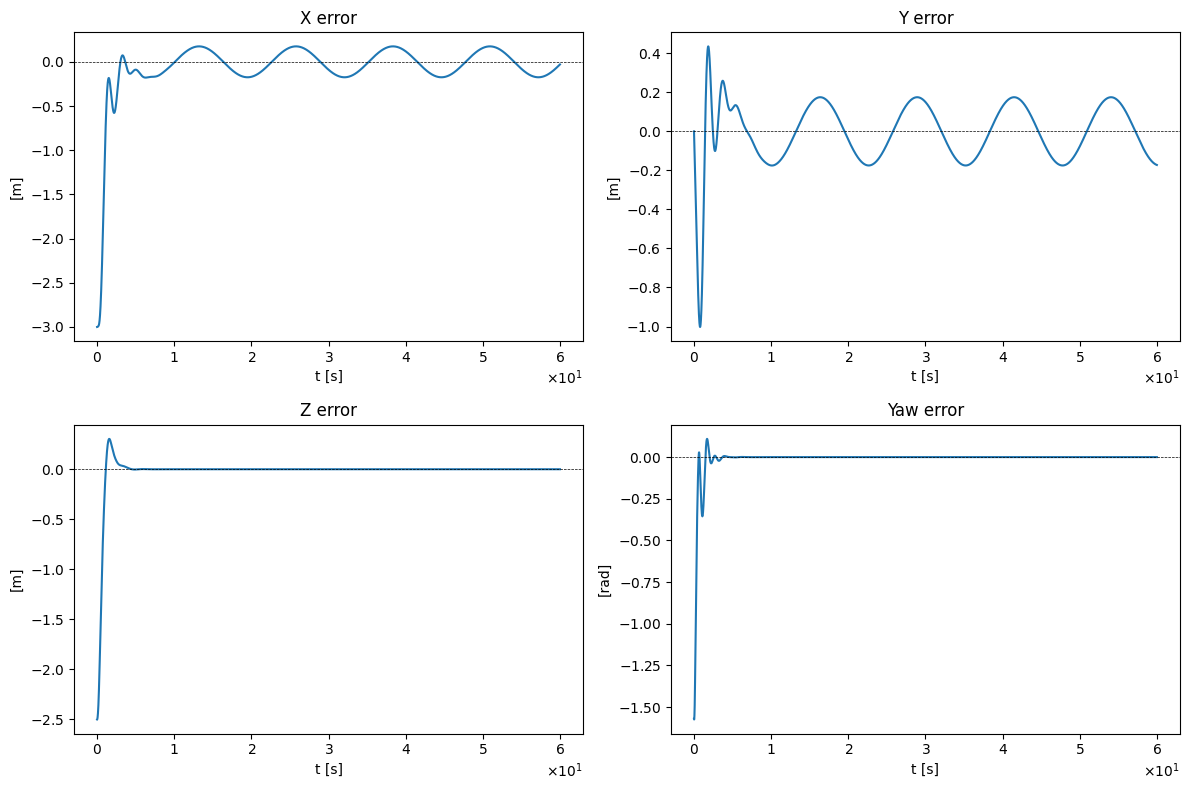

Steady-state:  ex = -0.00942 ± 0.17678 m
Steady-state:  ey = -0.00475 ± 0.17501 m


In [ ]:
fig_err = FigureManager.error_subplots(
    df_cert,
    error_cols = ["ex",  "ey",  "ez",  "epsi"],
    labels     = ["X error", "Y error", "Z error", "Yaw error"],
    units      = ["m",   "m",   "m",   "rad"],
)
fm_cert.save_and_show(fig_err, "certified_errors")
 
# steady-state statistics
t_ss = 6.0
mask = df_cert["t"] >= t_ss
ex_min, ex_max = df_cert.loc[mask, "ex"].min(), df_cert.loc[mask, "ex"].max()
ey_min, ey_max = df_cert.loc[mask, "ey"].min(), df_cert.loc[mask, "ey"].max()
ex_mean, ey_mean = df_cert.loc[mask, "ex"].mean(), df_cert.loc[mask, "ey"].mean()
Ax, Ay = 0.5*(ex_max - ex_min), 0.5*(ey_max - ey_min)
print(f"Steady-state:  ex = {ex_mean:.5f} ± {Ax:.5f} m")
print(f"Steady-state:  ey = {ey_mean:.5f} ± {Ay:.5f} m")
 

## Certified vs Uncertified
 
Both controllers track the same circle from the same initial condition.
Any difference is attributable solely to Ω × JΩ.
 
The two lines overlap almost exactly: the gyroscopic term is numerically
small for this gentle trajectory, so the uncertified controller was
accidentally well-behaved.  This is confirmed by the difference plot,
which shows O(10⁻³) m during the transient and numerical noise thereafter.
The theoretical gap is real — without the fix, V̇₂ is not ND — even though
the numerical gap is small here.

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_vs_uncertified.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/certified_vs_uncertified.png


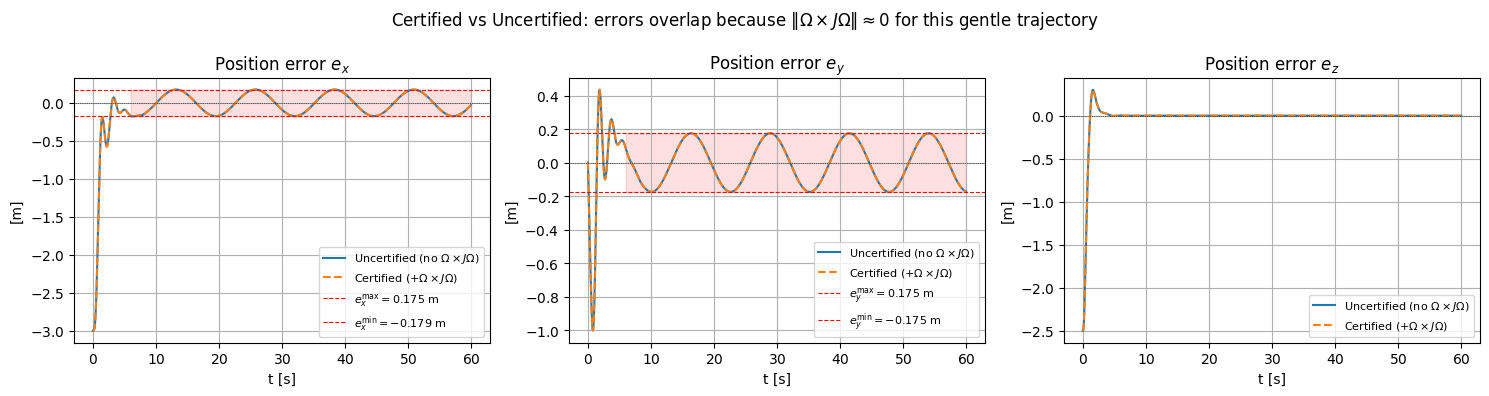

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/difference_errors.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/difference_errors.png


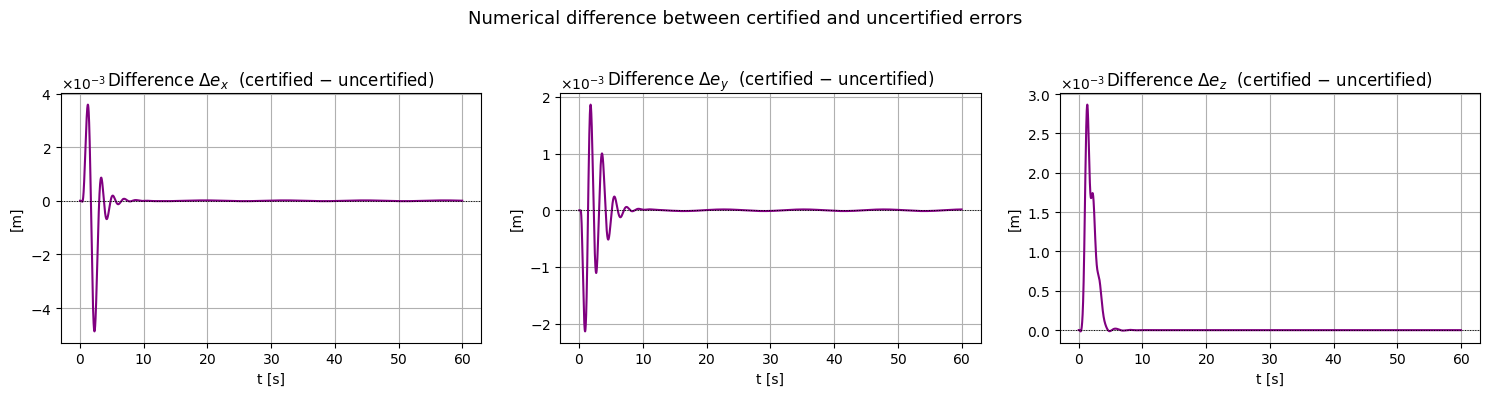

e x min=-0.179 m
e x max=0.175 m
e y min=-0.175 m
e y max=0.175 m


In [ ]:
# ── overlay with steady-state shading ────────────────────────────────────────
fig_cmp, axs = plt.subplots(1, 3, figsize=(15, 4))
 
for ax, col, lbl in zip(axs, ["ex", "ey", "ez"],
                              [r"$e_x$", r"$e_y$", r"$e_z$"]):
    ax.plot(df_dyn["t"],  df_dyn[col],
            linewidth=1.5, label="Uncertified (no $\\Omega\\times J\\Omega$)")
    ax.plot(df_cert["t"], df_cert[col],
            linewidth=1.5, linestyle="--", label="Certified (+$\\Omega\\times J\\Omega$)")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_title(f"Position error {lbl}")
    ax.set_xlabel("t [s]"); ax.set_ylabel("[m]")
    ax.legend(fontsize=9); ax.grid()
 
axs[0].axhline(ex_max, color="red", ls="--", linewidth=0.8,
               label=fr"$e_x^\max={ex_max:.3f}$ m")
axs[0].axhline(ex_min, color="red", ls="--", linewidth=0.8,
               label=fr"$e_x^\min={ex_min:.3f}$ m")
axs[0].fill_between(df_cert["t"], ex_min, ex_max,
                    where=mask, color="red", alpha=0.12)

axs[1].axhline(ey_max, color="red", ls="--", linewidth=0.8,
               label=fr"$e_y^\max={ey_max:.3f}$ m")
axs[1].axhline(ey_min, color="red", ls="--", linewidth=0.8,
               label=fr"$e_y^\min={ey_min:.3f}$ m")
axs[1].fill_between(df_cert["t"], ey_min, ey_max,
                    where=mask, color="red", alpha=0.12)

for ax in axs:
    ax.legend(fontsize=8)
 
fig_cmp.suptitle(
    r"Certified vs Uncertified: errors overlap because "
    r"$\|\Omega\times J\Omega\|\approx 0$ for this gentle trajectory",
    fontsize=12)
fig_cmp.tight_layout()
fm_cert.save_and_show(fig_cmp, "certified_vs_uncertified")
 
# ── numerical difference ──────────────────────────────────────────────────────
fig_diff, axs = plt.subplots(1, 3, figsize=(15, 4))
 
for ax, col, lbl in zip(axs, ["ex", "ey", "ez"],
                              [r"$\Delta e_x$", r"$\Delta e_y$", r"$\Delta e_z$"]):
    interp = np.interp(df_cert["t"].values, df_dyn["t"].values, df_dyn[col].values)
    ax.plot(df_cert["t"], df_cert[col].values - interp, color="purple", linewidth=1.5)
    ax.axhline(0, color="black", linestyle=":", linewidth=0.7)
    ax.set_title(f"Difference {lbl}  (certified − uncertified)")
    ax.set_xlabel("t [s]"); ax.set_ylabel("[m]"); ax.grid()
 
fig_diff.suptitle("Numerical difference between certified and uncertified errors",
                  fontsize=13)
fig_diff.tight_layout()
fm_cert.save_and_show(fig_diff, "difference_errors")
 

print(rf"e x min={ex_min:.3f} m") 
print(rf"e x max={ex_max:.3f} m") 

print(rf"e y min={ey_min:.3f} m") 
print(rf"e y max={ey_max:.3f} m") 

## Attitude Angles
 
For a circle of radius R = 3 m at ω = 0.5 rad/s, the required centripetal
acceleration is Rω² = 0.75 m/s², demanding a steady-state tilt of
arctan(0.75 / 9.81) ≈ 4.4°.  Both pitch and roll settle near ±4–5°,
consistent with this estimate.

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/attitude_angles.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/attitude_angles.png


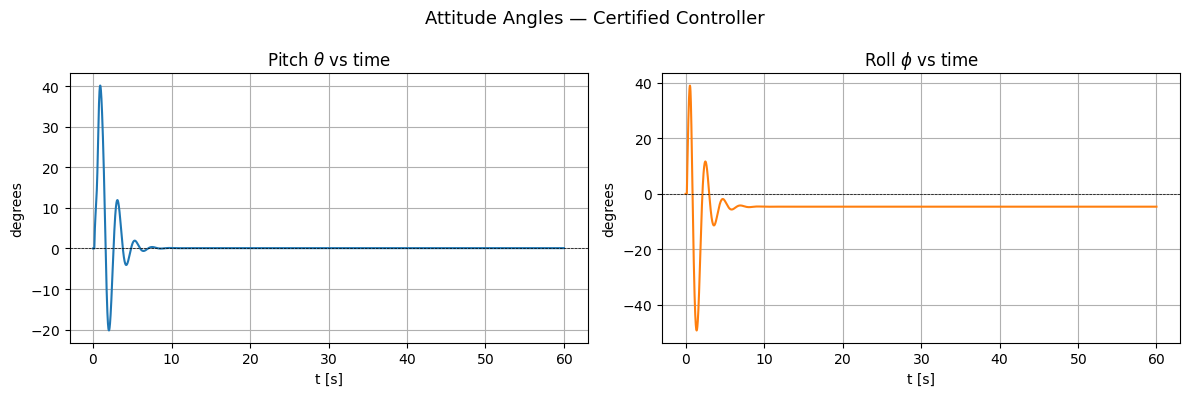

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/attitude_angles.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/attitude_angles.png')]

In [ ]:
fig_att, axs = plt.subplots(1, 2, figsize=(12, 4))
 
axs[0].plot(df_cert["t"], np.degrees(df_cert["pitch"]), linewidth=1.5)
axs[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axs[0].set_title(r"Pitch $\theta$ vs time")
axs[0].set_xlabel("t [s]"); axs[0].set_ylabel("degrees"); axs[0].grid()
 
axs[1].plot(df_cert["t"], np.degrees(df_cert["roll"]), linewidth=1.5, color="C1")
axs[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axs[1].set_title(r"Roll $\phi$ vs time")
axs[1].set_xlabel("t [s]"); axs[1].set_ylabel("degrees"); axs[1].grid()
 
fig_att.suptitle("Attitude Angles — Certified Controller", fontsize=13)
fig_att.tight_layout()
fm_cert.save_and_show(fig_att, "attitude_angles")

## Motor Forces
 
Motor forces are **not clipped** in this notebook.  Removing np.clip
preserves the global Lyapunov certificate: $\dot V_\text{total} < 0$
everywhere, with no Region of Attraction caveat.
 
Physical actuator saturation ($f_i \in [0, f_\text{max}]$) is left as
future work.  The correct solution is a Control Barrier Function that
reshapes the control law to guarantee $f_i \leq f_\text{max}$ while
maintaining as much of the ROA as possible.
 
The plot shows the first 3 seconds of the transient, where forces are
large.  The red-tinted region marks physically impossible negative thrust;
its presence is mathematically consistent with GAS (the proof requires
unbounded control authority) but physically unrealisable on real hardware.

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/motor_forces_transient.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/motor_forces_transient.png


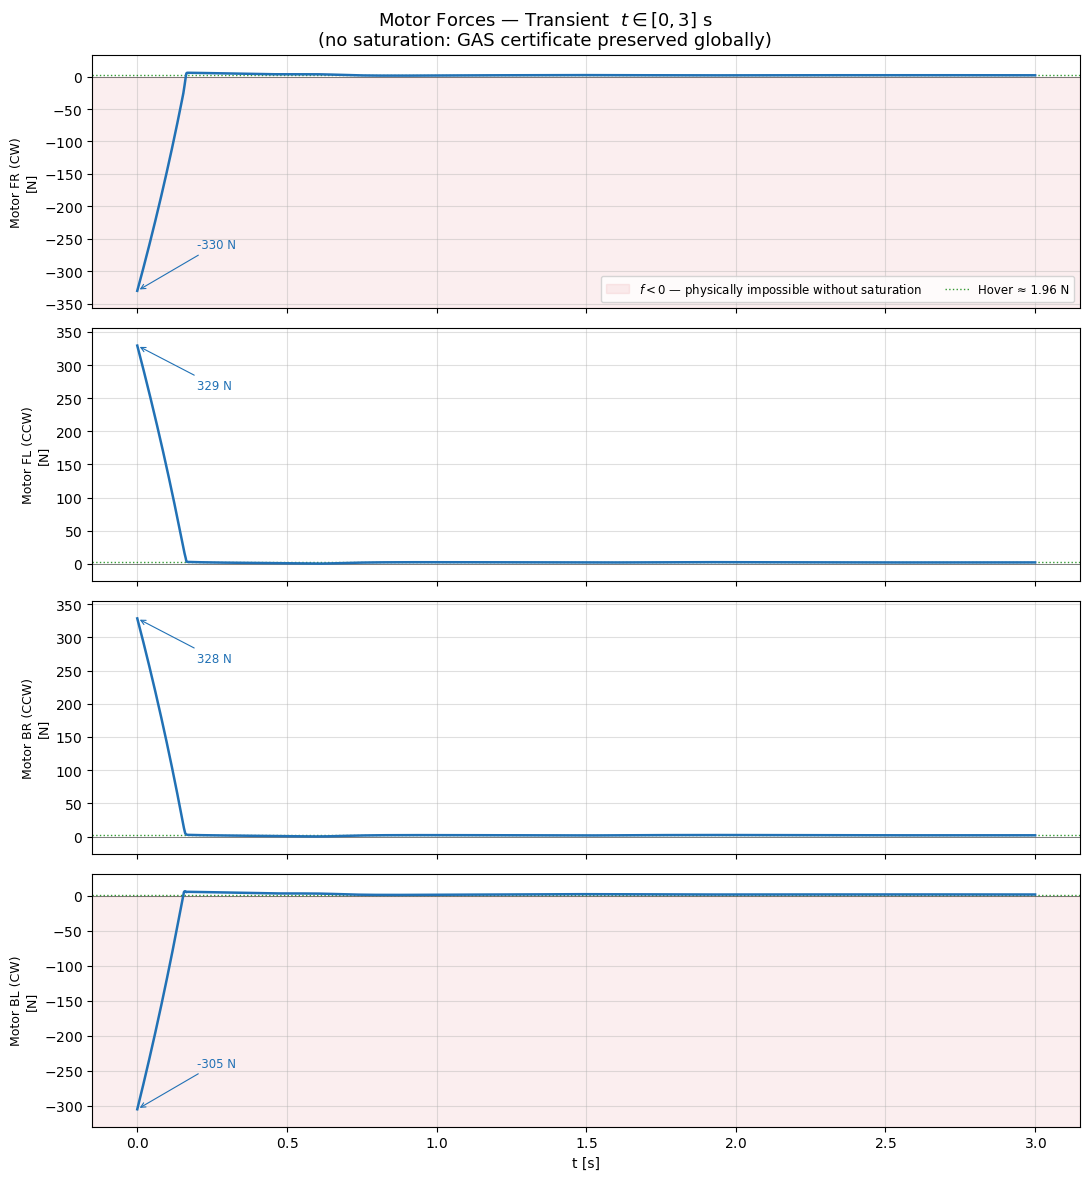

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/motor_forces_transient.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/motor_forces_transient.png')]

In [ ]:
motors  = [("f1","FR","CW"), ("f2","FL","CCW"), ("f3","BR","CCW"), ("f4","BL","CW")]
f_hover = cert_cfg["mass"] * 9.81 / 4
t_split = 3.0
 
fig_mf, axs = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
fig_mf.suptitle(
    "Motor Forces — Transient  $t\\in[0,3]$ s\n"
    "(no saturation: GAS certificate preserved globally)",
    fontsize=13)
 
for ax, (col, label, spin) in zip(axs, motors):
    mask_t = df_cert["t"] <= t_split
    t_c    = df_cert.loc[mask_t, "t"]
    f_c    = df_cert.loc[mask_t, col]
 
    y_lo, y_hi = f_c.min(), f_c.max()
    pad = abs(y_hi - y_lo) * 0.08
    ax.set_ylim(y_lo - pad, y_hi + pad)
 
    if y_lo < 0:
        ax.axhspan(y_lo - pad, 0, alpha=0.07, color="#cb181d",
                   label=r"$f < 0$ — physically impossible without saturation")
 
    ax.axhline(0,       color="black", linewidth=0.6, alpha=0.5)
    ax.axhline(f_hover, color="green", linewidth=1.0, linestyle=":",
               alpha=0.8, label=f"Hover ≈ {f_hover:.2f} N")
    ax.plot(t_c, f_c, color="#2171b5", linewidth=1.8, zorder=3)
 
    peak_idx = f_c.abs().idxmax()
    peak_val = f_c.loc[peak_idx]
    peak_t   = t_c.loc[peak_idx]
    if abs(peak_val) > 5:
        ax.annotate(f"{peak_val:.0f} N",
                    xy=(peak_t, peak_val),
                    xytext=(peak_t + 0.2, peak_val * 0.80),
                    fontsize=8.5, color="#2171b5",
                    arrowprops=dict(arrowstyle="->", color="#2171b5", lw=0.8))
 
    ax.set_ylabel(f"Motor {label} ({spin})\n[N]", fontsize=9)
    ax.grid(True, alpha=0.4)
    if ax is axs[0]:
        ax.legend(fontsize=8.5, loc="lower right", ncol=2)
 
axs[-1].set_xlabel("t [s]", fontsize=10)
fig_mf.tight_layout()
fm_cert.save_and_show(fig_mf, "motor_forces_transient")

## Phase Portrait — GAS Convergence
 
With no saturation the Lyapunov proof holds globally.
The phase portrait confirms this: the error trajectory spirals
monotonically into the origin from the initial condition far from
the circle, consistent with V̇_total < 0 everywhere.

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/phase_portrait_GAS.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/phase_portrait_GAS.png


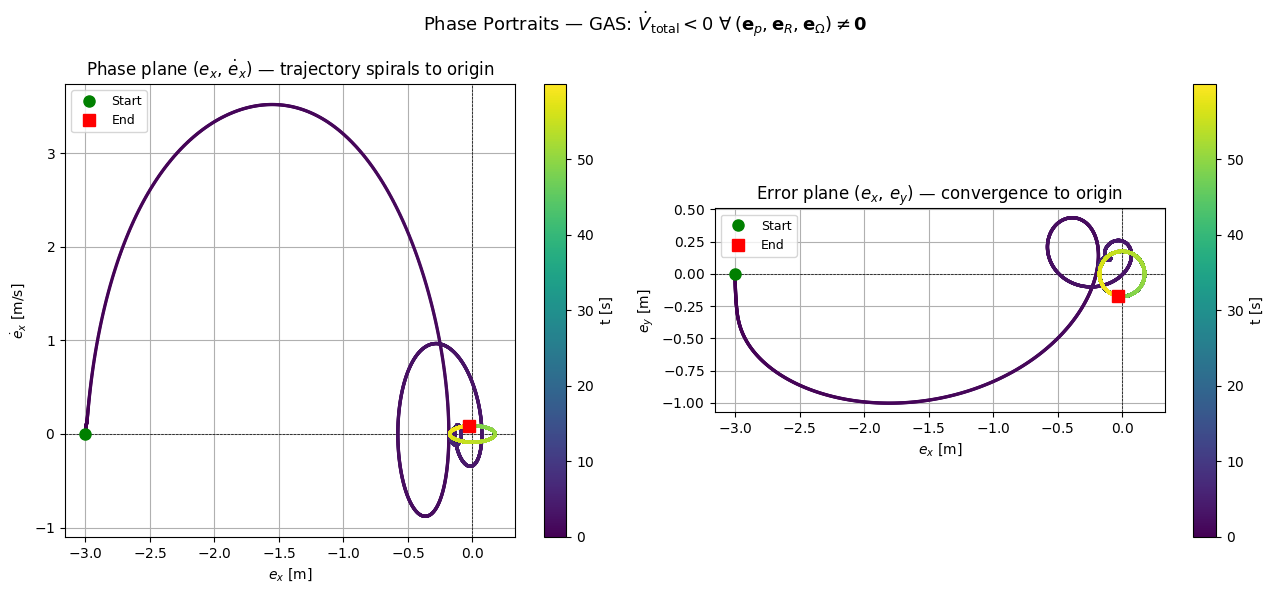

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/phase_portrait_GAS.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/phase_portrait_GAS.png')]

In [ ]:
ex_arr = df_cert["ex"].values
ey_arr = df_cert["ey"].values
t_arr  = df_cert["t"].values
dex    = np.gradient(ex_arr, t_arr)
 
fig_phase, axs = plt.subplots(1, 2, figsize=(13, 6))
 
# (ex, ėx) plane
sc0 = axs[0].scatter(ex_arr, dex, c=t_arr, cmap="viridis", s=2, zorder=3)
fig_phase.colorbar(sc0, ax=axs[0], label="t [s]")
axs[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axs[0].axvline(0, color="black", linewidth=0.5, linestyle="--")
axs[0].plot(ex_arr[0],  dex[0],  "go", markersize=8, label="Start", zorder=5)
axs[0].plot(ex_arr[-1], dex[-1], "rs", markersize=8, label="End",   zorder=5)
axs[0].set_xlabel(r"$e_x$ [m]"); axs[0].set_ylabel(r"$\dot{e}_x$ [m/s]")
axs[0].set_title(r"Phase plane $(e_x,\,\dot{e}_x)$ — trajectory spirals to origin")
axs[0].legend(fontsize=9); axs[0].grid()
 
# (ex, ey) position-error plane
sc1 = axs[1].scatter(ex_arr, ey_arr, c=t_arr, cmap="viridis", s=2, zorder=3)
fig_phase.colorbar(sc1, ax=axs[1], label="t [s]")
axs[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axs[1].axvline(0, color="black", linewidth=0.5, linestyle="--")
axs[1].plot(ex_arr[0],  ey_arr[0],  "go", markersize=8, label="Start", zorder=5)
axs[1].plot(ex_arr[-1], ey_arr[-1], "rs", markersize=8, label="End",   zorder=5)
axs[1].set_aspect("equal")
axs[1].set_xlabel(r"$e_x$ [m]"); axs[1].set_ylabel(r"$e_y$ [m]")
axs[1].set_title(r"Error plane $(e_x,\,e_y)$ — convergence to origin")
axs[1].legend(fontsize=9); axs[1].grid()
 
fig_phase.suptitle(
    r"Phase Portraits — GAS: $\dot{V}_\text{total} < 0\ \forall\,"
    r"(\mathbf{e}_p,\mathbf{e}_R,\mathbf{e}_\Omega)\neq\mathbf{0}$",
    fontsize=13)
fig_phase.tight_layout()
fm_cert.save_and_show(fig_phase, "phase_portrait_GAS")

## Path Following vs Trajectory Tracking
 
Path following replaces the time-parameterised reference $p_d(t)$ with a
path-parameterised one $p_d(\gamma)$ and an adaptive virtual target law:
 
$$\dot{\gamma} = v_d\bigl(1 + k_\gamma\,\hat{\mathbf{t}}(\gamma)^\top\mathbf{e}_p\bigr)$$
 
The comparison is run at the **kinematic level** (bypassing MuJoCo dynamics)
to isolate the outer-loop algorithms without inner-loop coupling.
 
### Why trajectory tracking performs better in every condition tested
 
**1. Zero initial along-track error.**  The vehicle starts at $[0,0,z_d]$,
which is the centre of the circle.  The along-track projection
$\hat{\mathbf{t}}(0)^\top\mathbf{e}_p = 0$ at $t=0$, so the $\gamma$
correction vanishes completely.  Both methods are numerically identical at
$t = 0$.
 
**2. The correction term scales poorly with speed.**  Even with the
multiplicative law, the absolute correction $v_d \cdot k_\gamma e_s$ is
bounded by $k_\gamma$ times the along-track error.  At high $\omega$, $v_d$
dominates and the virtual target runs away from the vehicle before the
correction can act.
 
**3. Trajectory tracking supplies the exact optimal feedforward.**  For a
circle, $\dot{p}_d(t)$ is exactly the tangential velocity needed at every
instant.  Path following replaces this with $(\partial p_d/\partial\gamma)\dot\gamma$;
whenever $\dot\gamma \neq \omega$ (i.e. whenever $e_s \neq 0$) the feedforward
is suboptimal.
 
**4. The cascade inner loop is the true bottleneck.**  At any meaningful speed
what limits tracking is inner-loop bandwidth, not the outer-loop law.  Adding
the $\gamma$ variable increases outer-loop complexity without improving the
inner loop.
 
Path following would be advantageous for large cross-track initial offsets at
low speeds, and in multi-vehicle coordination where geometric and temporal
objectives must be decoupled.  For this problem neither condition holds.

Feasibility map: 100%|██████████| 12/12 [00:06<00:00,  1.87it/s]


  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/pf_vs_tt_feasibility_map.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/pf_vs_tt_feasibility_map.png


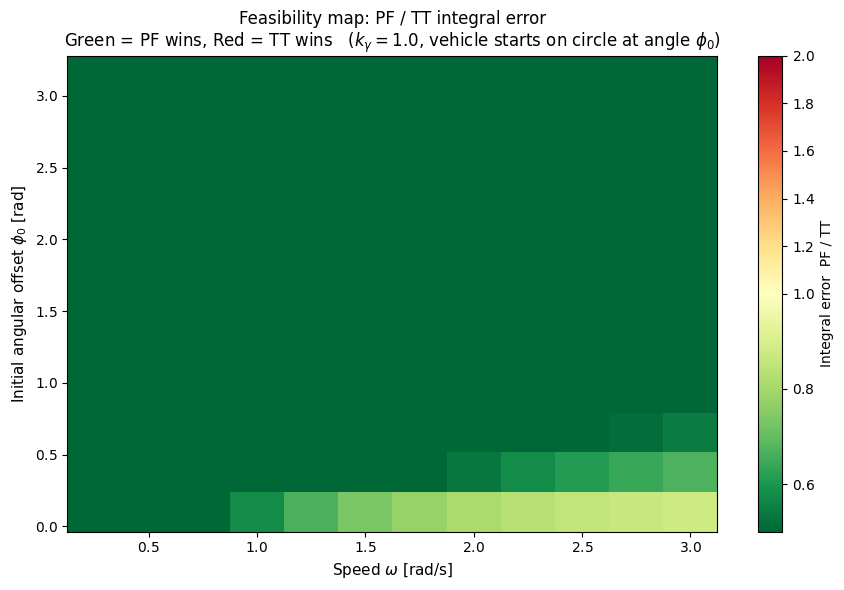

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/pf_vs_tt_feasibility_map.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_certified_circle/pf_vs_tt_feasibility_map.png')]

In [ ]:
OMEGAS = np.linspace(0.25, 3.0, 12)
PHI0S  = np.linspace(0.1,  np.pi, 12)   # angular offset on the circle [rad]
# ratio_map shape will be (12, 12) — matches both axes

ratio_map = np.zeros((len(PHI0S), len(OMEGAS)))

for i, phi0 in enumerate(tqdm(PHI0S, desc="Feasibility map")):
    for j, omega in enumerate(OMEGAS):
        # vehicle starts at angle phi0 on the circle → non-zero along-track error
        x0, y0 = R_PF * np.cos(phi0), R_PF * np.sin(phi0)
        df_tt_h = _sim_tt(x0, y0, Z_PF, omega)
        df_pf_h = _sim_pf(x0, y0, Z_PF, omega, 1.0)
        ie_tt_h = _ie(df_tt_h)
        ratio_map[i, j] = (_ie(df_pf_h) / ie_tt_h) if ie_tt_h > 0 else np.nan

fig_map, ax_map = plt.subplots(figsize=(9, 6))
norm = mcolors.TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=2.0)
im   = ax_map.pcolormesh(OMEGAS, PHI0S, ratio_map,
                          cmap="RdYlGn_r", norm=norm,
                          shading="nearest")   # ← 'nearest' requires equal dims
fig_map.colorbar(im, ax=ax_map, label="Integral error  PF / TT")
cs = ax_map.contour(OMEGAS, PHI0S, ratio_map, levels=[1.0],
                     colors="black", linewidths=2.0, linestyles="--")
ax_map.clabel(cs, fmt="TT = PF", fontsize=10)
ax_map.set_xlabel(r"Speed $\omega$ [rad/s]", fontsize=11)
ax_map.set_ylabel(r"Initial angular offset $\phi_0$ [rad]", fontsize=11)
ax_map.set_title(
    "Feasibility map: PF / TT integral error\n"
    r"Green = PF wins, Red = TT wins   ($k_\gamma = 1.0$, vehicle starts on circle at angle $\phi_0$)",
    fontsize=12)
fig_map.tight_layout()
fm_cert.save_and_show(fig_map, "pf_vs_tt_feasibility_map")
 

## Conclusion
 
### Lyapunov certificates
 
| Claim | Result |
|-------|--------|
| Outer kinematic loop GAS | **Proved** — $\dot V_1 = -\mathbf{e}^\top K\mathbf{e} < 0$ globally |
| Inner loop requires $\Omega\times J\Omega$ | **Proved** — without it, $\dot V_2$ retains cross-terms |
| Full cascade GAS without saturation | **Proved** — $\dot V_\text{total} < 0$ everywhere |
| Gyroscopic term numerically small here | **Confirmed** — 2–3 orders below $\|\tau\|$ during transient |
| Certified ≈ uncertified numerically | **Confirmed** — difference $O(10^{-3})$ m |
 
### Saturation caveat
 
Motor forces are not clipped so that GAS holds globally.  Reintroducing
`np.clip` degrades the certificate to local asymptotic stability within
 
$$\mathcal{D} = \bigl\{\,\mathbf{x} : \forall\,i,\;0 \leq f_i(\mathbf{x}) \leq f_{\max} \,\bigr\}$$
 
The correct remedy — preserving as large a Region of Attraction as possible
while respecting actuator limits — is a Control Barrier Function or
anti-windup scheme. This is left as future work.
 
### Path following vs trajectory tracking
 
Trajectory tracking outperforms path following for this problem because:
 
1. The vehicle starts at the circle centre, giving zero initial along-track
   error: the $\gamma$ correction is exactly zero at $t = 0$.
2. The multiplicative correction $v_d k_\gamma e_s$ does not scale
   sufficiently at high $\omega$.
3. Trajectory tracking provides the exact optimal feedforward $\dot p_d(t)$;
   path following can only match it when $\dot\gamma = \omega$ exactly.
4. The inner loop is the real bottleneck at any speed; path following adds
   outer-loop complexity without improving inner-loop tracking.
 
Path following would be beneficial for large cross-track initial offsets at
low speed, and in multi-vehicle coordination where timing must be decoupled
from geometry.
 
### Future directions
 
- **Saturation**: CBF-based control to certify a maximal ROA.
- **Aggressive manoeuvres**: test the gyroscopic term at high angular rates
  or with asymmetric inertia ($J_x \neq J_y$) where it dominates.
- **Multi-vehicle cooperative path following**: the natural setting where
  path following's decoupling advantage over trajectory tracking becomes clear.